In [15]:
import torch
import pandas as pd
from d2l import torch as d2l
import os
import torchvision
d2l.DATA_HUB['banana-detection'] = (
    d2l.DATA_URL + 'banana-detection.zip',
    '5de26c8fce5ccdea9f91267273464dc968d20d72')

In [ ]:
def read_data_bananas(is_train=True):
    data_dir=d2l.download_extract('banana-detection')
    csv_name=os.path.join(data_dir,'bananas_train' if is_train else 'bananas_val','label.csv')
    csv_data=pd.read_csv(csv_name)
    # 把img_name作为索引
    csv_data=csv_data.set_index('img_name')
    images, targets=[],[]
    for img_name,target in csv_data.iterrows():
        # 把train or val的图片转成Tensor并加入images
        images.append(torchvision.io.read_image(os.path.join(data_dir,'bananas_train' if is_train else 'bananas_val','images',img_name)))
        # target包含非index的列，需要转成Tensor并除以256
        targets.append(target)
    return images, torch.tensor(targets).unsqueeze(1) / 256  # 除以256是为了将目标值缩放到0-1之间

In [55]:
class BananasDataset(torch.utils.data.Dataset):
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read', len(self.features), 'images for ', 'train' if is_train else 'test')
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]
    def __len__(self):
        return len(self.features)

In [57]:
my_list=[1,2,3,4,5]
iter_list=iter(my_list)
for i in range(5):
    print(next(iter_list))

1
2
3
4
5


In [56]:
def load_data_bananas(batch_size):
    """加载香蕉检测数据集"""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

In [ ]:
batch_size=32
edge_size=256
train_iter, _=load_data_bananas(batch_size)
batch=next(iter(train_iter))

read 1000 images for  train
read 100 images for  test


tensor([[[[  0,   0,   0,  ...,   0,   0,   0],
          [  0,   0,   0,  ...,   0,   0,   0],
          [  1,   1,   1,  ...,   0,   0,   0],
          ...,
          [  4,   4,   1,  ...,   0,   0,   2],
          [  4,   3,   3,  ...,   4,   5,   0],
          [  5,   2,   3,  ...,   1,   3,   0]],

         [[131, 133, 134,  ..., 140, 138, 137],
          [131, 133, 134,  ..., 140, 138, 138],
          [131, 133, 133,  ..., 140, 139, 139],
          ...,
          [  5,   5,   2,  ...,   1,   0,   2],
          [  3,   2,   4,  ...,   5,   5,   0],
          [  4,   1,   4,  ...,   2,   3,   0]],

         [[179, 181, 182,  ..., 196, 195, 194],
          [180, 181, 182,  ..., 196, 195, 195],
          [181, 182, 182,  ..., 196, 196, 196],
          ...,
          [  0,   0,   0,  ...,   0,   0,   4],
          [  0,   0,   0,  ...,   0,   7,   4],
          [  0,   0,   0,  ...,   0,   5,   5]]],


        [[[155, 154, 154,  ..., 147, 146, 146],
          [154, 154, 155,  ..., 147

In [64]:
print(batch[0].shape)
# 第一个batch的图像的形状
# 批量大小32，图像通道数为3，图像高为256，宽为256

# 第一个batch的label的形状
# （批量大小，m，5），其中m是数据集的任何图像中边界框可能出现的最大数量,由于每张图像上只有一个边界框，因此m=1。
print(batch[1].shape)

torch.Size([32, 3, 256, 256])
torch.Size([32, 1, 5])


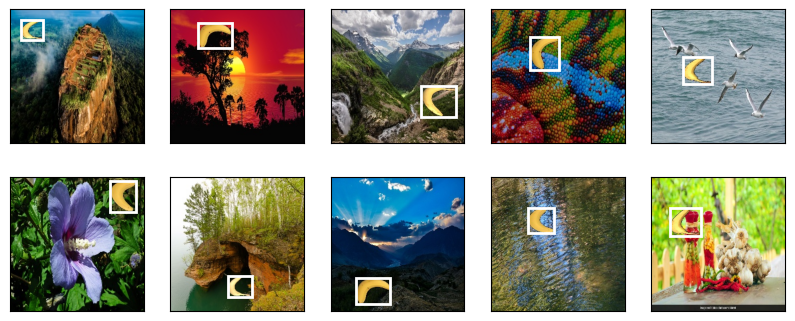

In [69]:
# .permute(0,2,3,1)： 这是在调整图像张量的维度顺序 /255： 这是将图像张量的像素值缩放到0-1之间
imgs=batch[0][:10].permute(0,2,3,1)/255
axes=d2l.show_images(imgs, 2, 5, scale=2)
for ax, label in zip(axes, batch[1][:10]):
    # 显示边界框 label[0][1:5]*256： 这是将边界框坐标从相对值转换为像素值
    d2l.show_bboxes(ax, [label[0][1:5]*256], colors=['w'])